# Visualizing the Sequence-Aware Trajectory Auditor
**Project:** Membership Inference Attacks via Adversarial Iterations

This notebook compiles the visual results of our four-stage deep learning pipeline. It demonstrates how a target model becomes vulnerable to privacy leaks, how we extract the "fingerprints" of those leaks, how our custom auditor learns to detect them, and finally, how well our auditor performs.

## Phase 1: Target Model Vulnerability
**Generated by:** `train_target.py`

Before we can catch a privacy leak, we need a model that leaks. We trained a standard ResNet-18 model on 25,000 images and hid another 25,000 images from it. These graphs show the model "overfitting" and memorizing its training data.

[Generalization Gap]
**What this shows:** The blue line is the model's accuracy on data it saw during training (nearly 100%). The orange line is its accuracy on new data (~70%). This massive gap means the model behaves very differently depending on whether it has seen an image before. This gap is the core vulnerability our attack exploits.

[Target Model Loss]
**What this shows:** This is a classic "overfitting" curve. The model's loss (confusion) on the training data drops to zero, meaning it is extremely confident. However, its confusion on unseen data starts to climb back up.

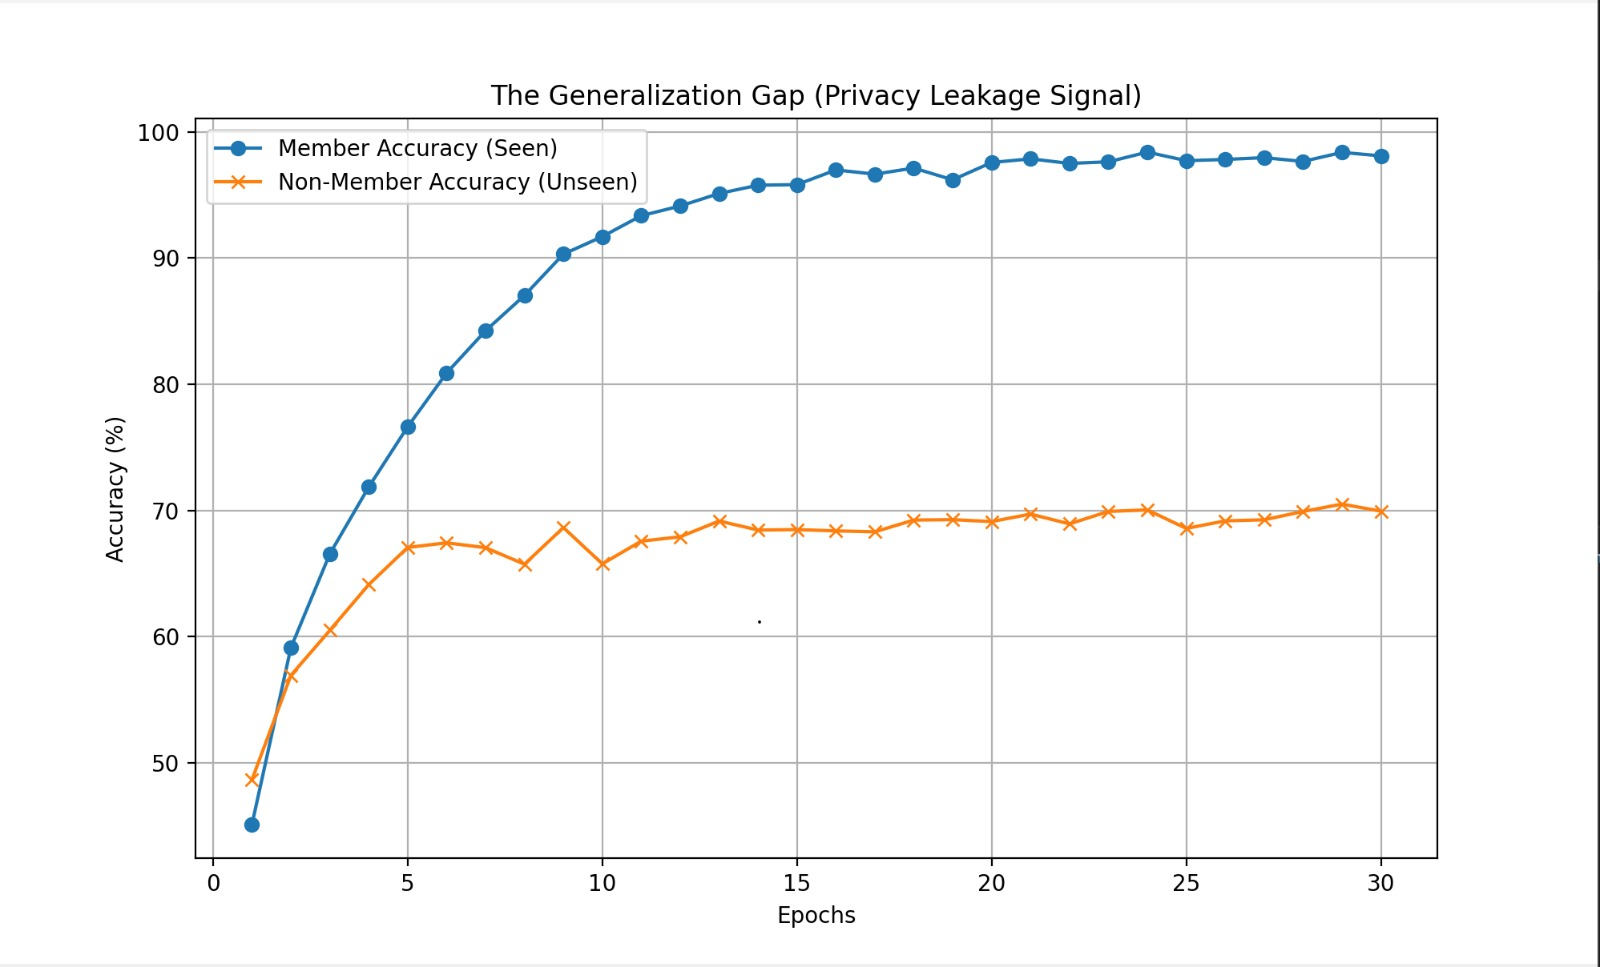

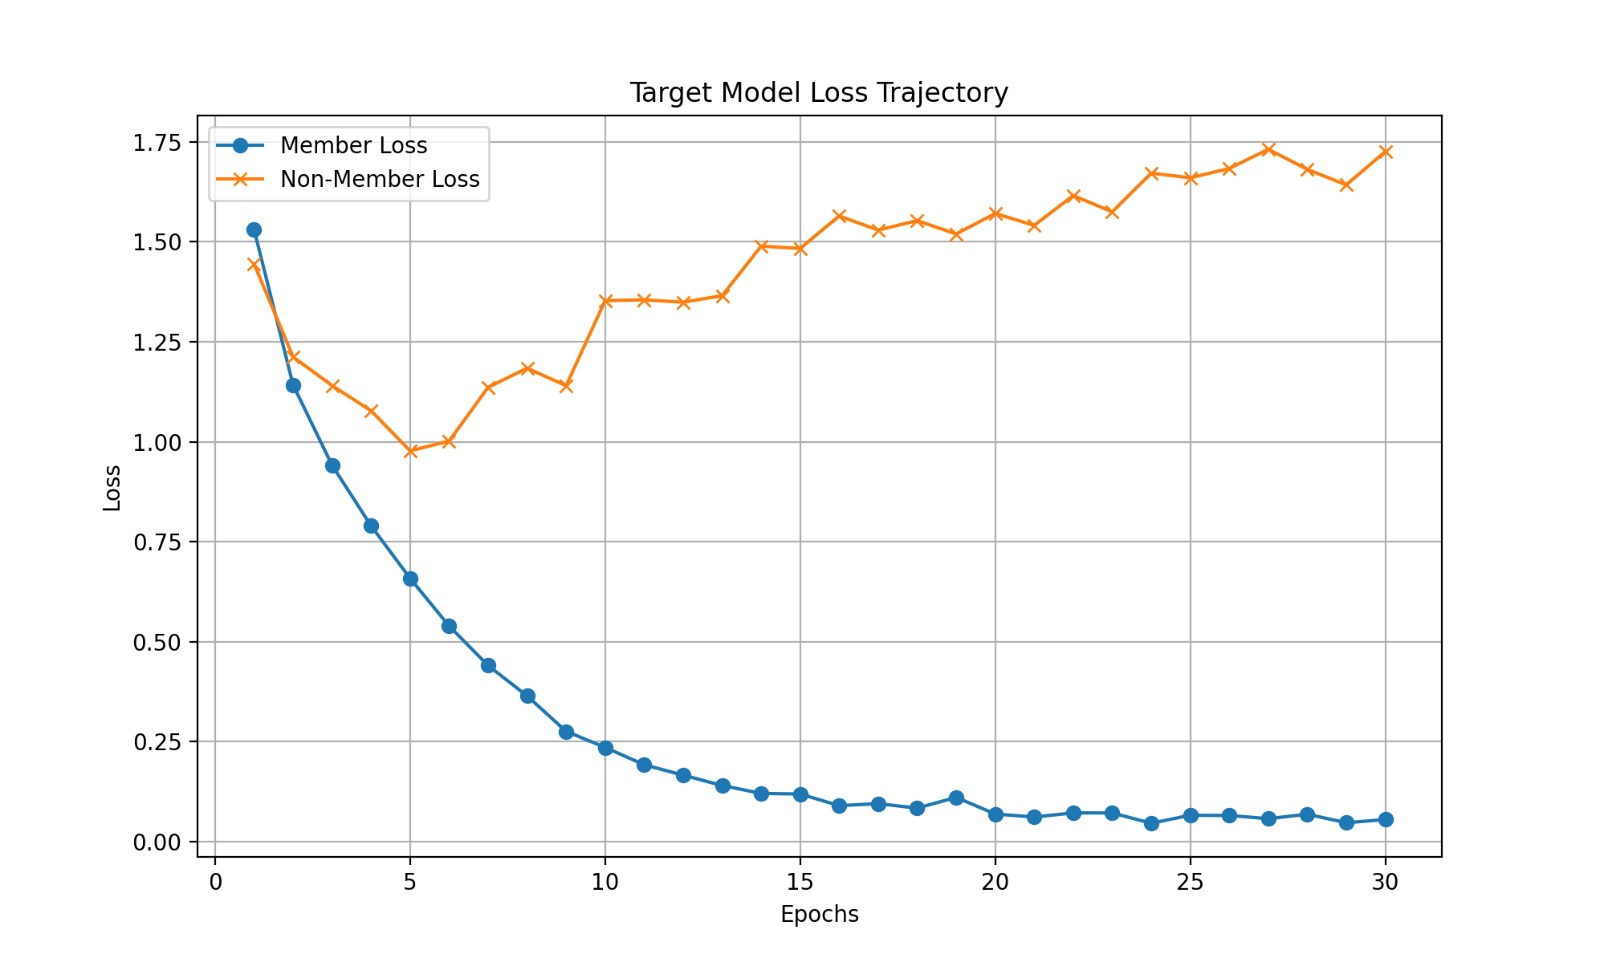

## Phase 2: Adversarial Trajectory Extraction
**Generated by:** `generate_data.py`

The model was attacked for 20 steps using PGD. Loss and confidence were recorded at every step to create a mathematical trajectory for each sample.

### 1. The Mean Trajectory
This plot averages 5,000 trajectories. Member lines stay lower and flatter because of memorization. Non-member loss spikes quickly because the model never saw those samples during training.

### 2. Adversarial Image Evolution
Visual progression of the PGD attack. The added noise is subtle enough that humans still recognize the image, but it effectively compromises the model's internal logic.

### 3. Final Step Confidence Distribution
A snapshot of confidence at step 20. The model is consistently more confident on training data than unseen data. This persistent confidence difference is the leak the auditor exploits.

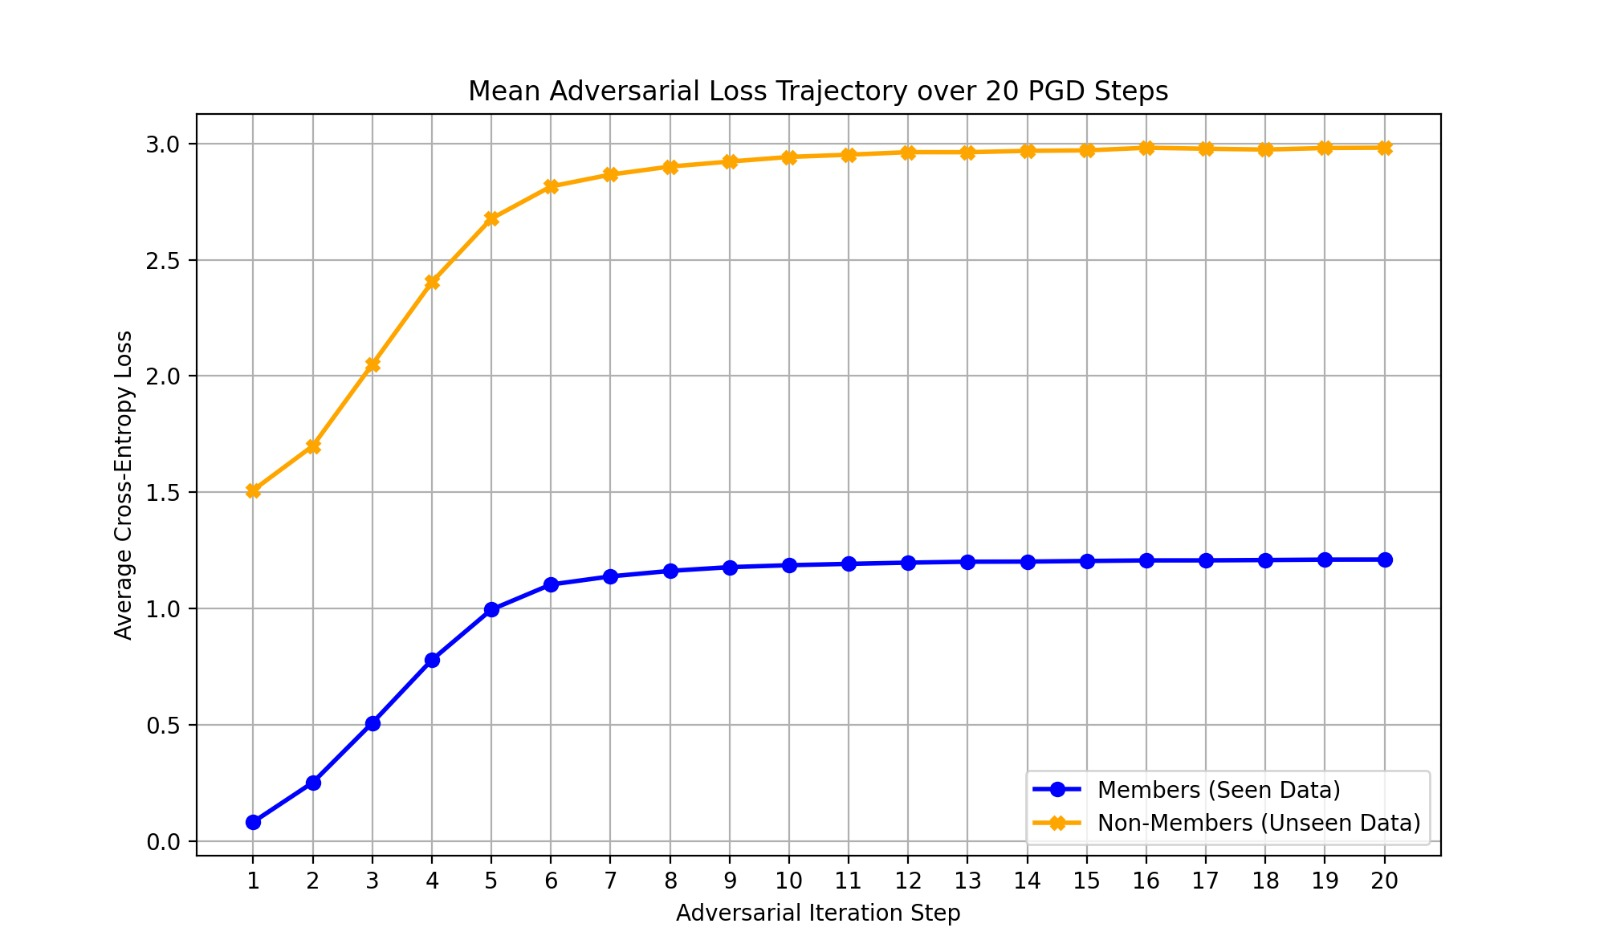

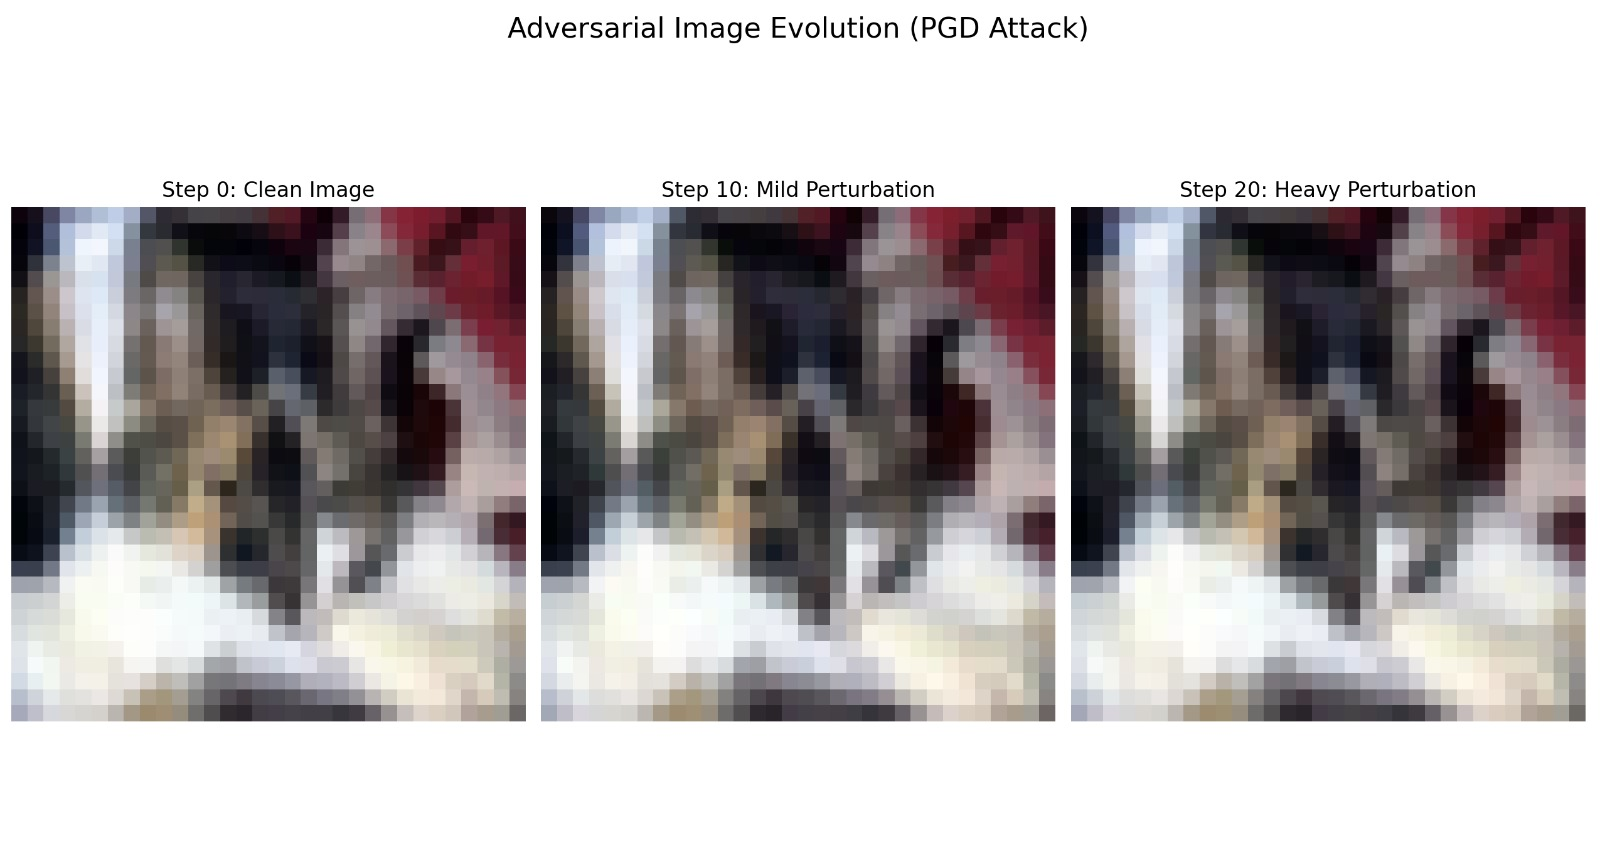

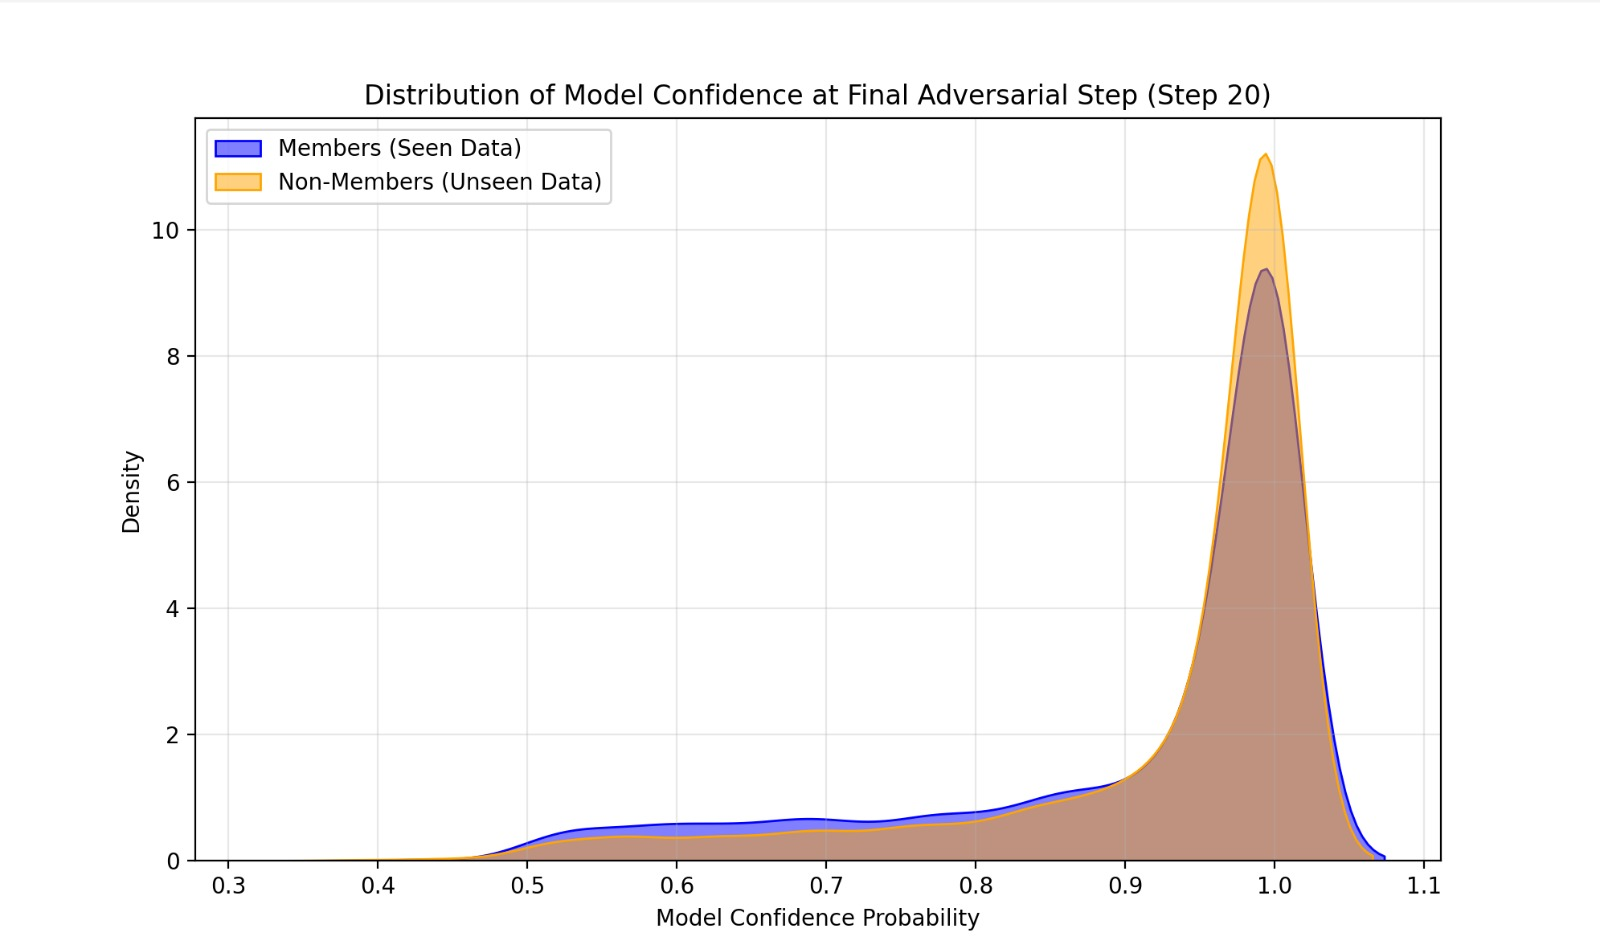

## Phase 3: Training the Sequence-Aware Auditor
**Generated by:** `train_auditor.py`

We took the 20-step trajectories from Phase 2 and fed them into our custom deep learning detective (an LSTM). The goal is to teach this detective to tell the difference between a Member trajectory and a Non-Member trajectory.

[Auditor Learning Curve]
**What this shows:** As the epochs go on, our detective gets better at guessing (Accuracy goes up). Because the yellow dashed line (Validation) stays close to the blue line (Training), it proves our detective is actually learning the general "rules" of a leak, rather than just cheating by memorizing the answers.

[Auditor Loss Convergence]
**What this shows:** The detective's loss (errors) steadily drops over 50 epochs, showing a healthy and stable training process.

[Detection Margin]
**What this shows:** This shows the detective's brain evolving! At Epoch 1, the blue and orange hills are completely mixed together (it's just guessing randomly). By Epoch 50, it has learned to pull the two groups apart, becoming very confident in identifying which is which.

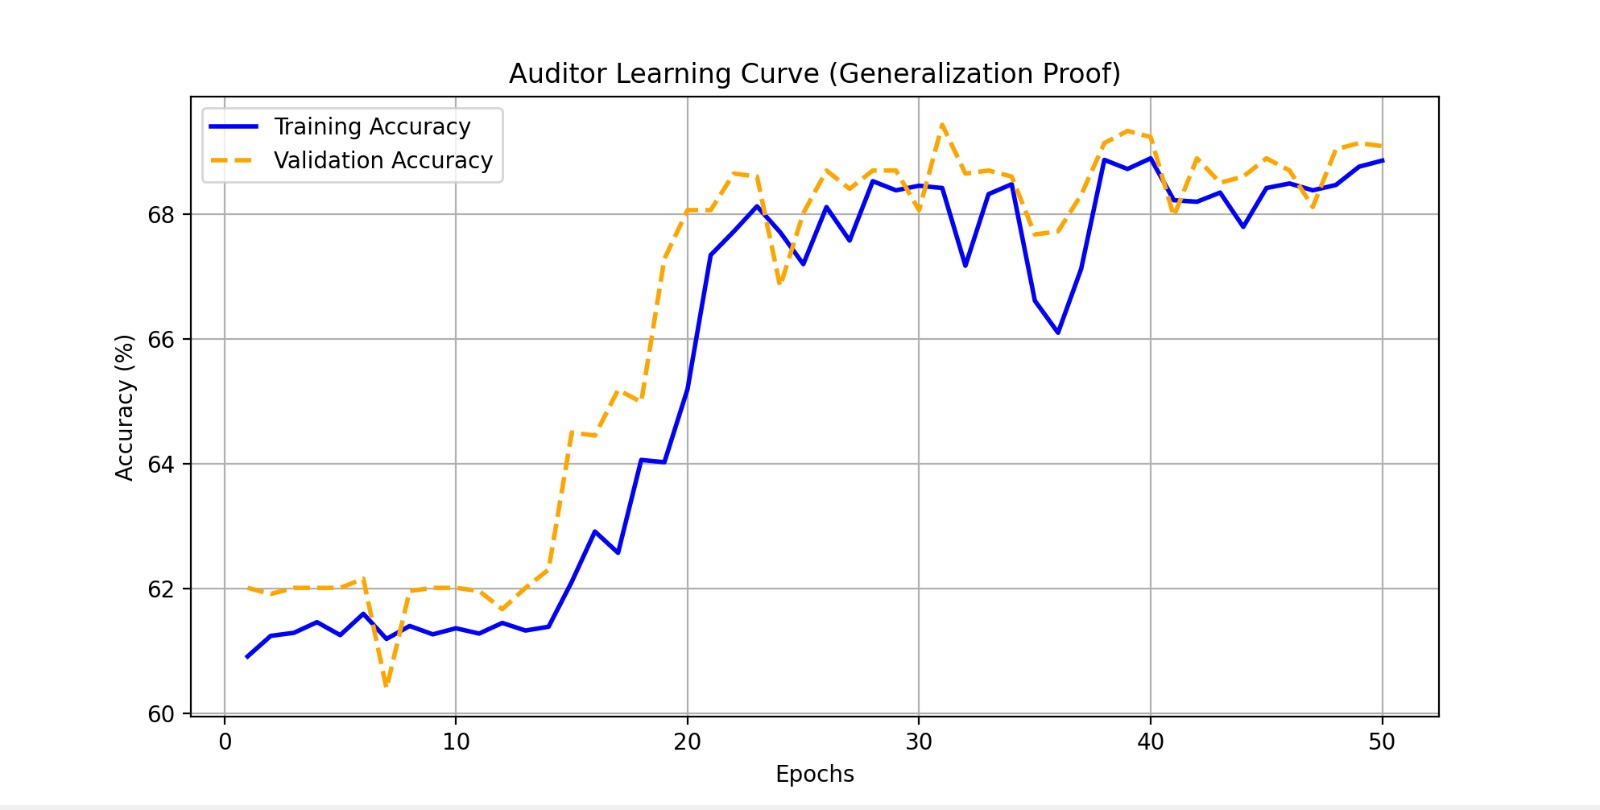

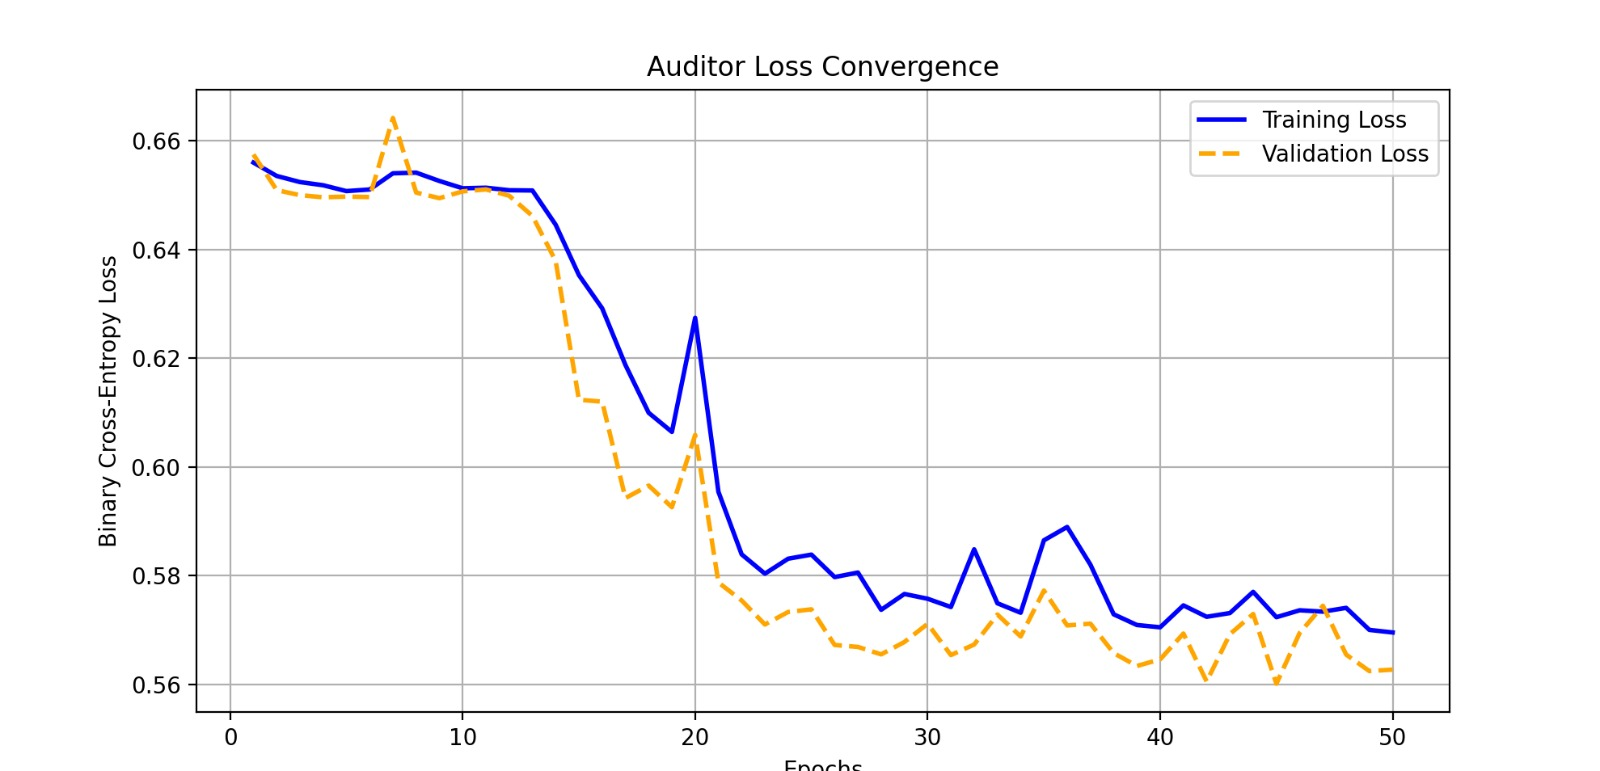

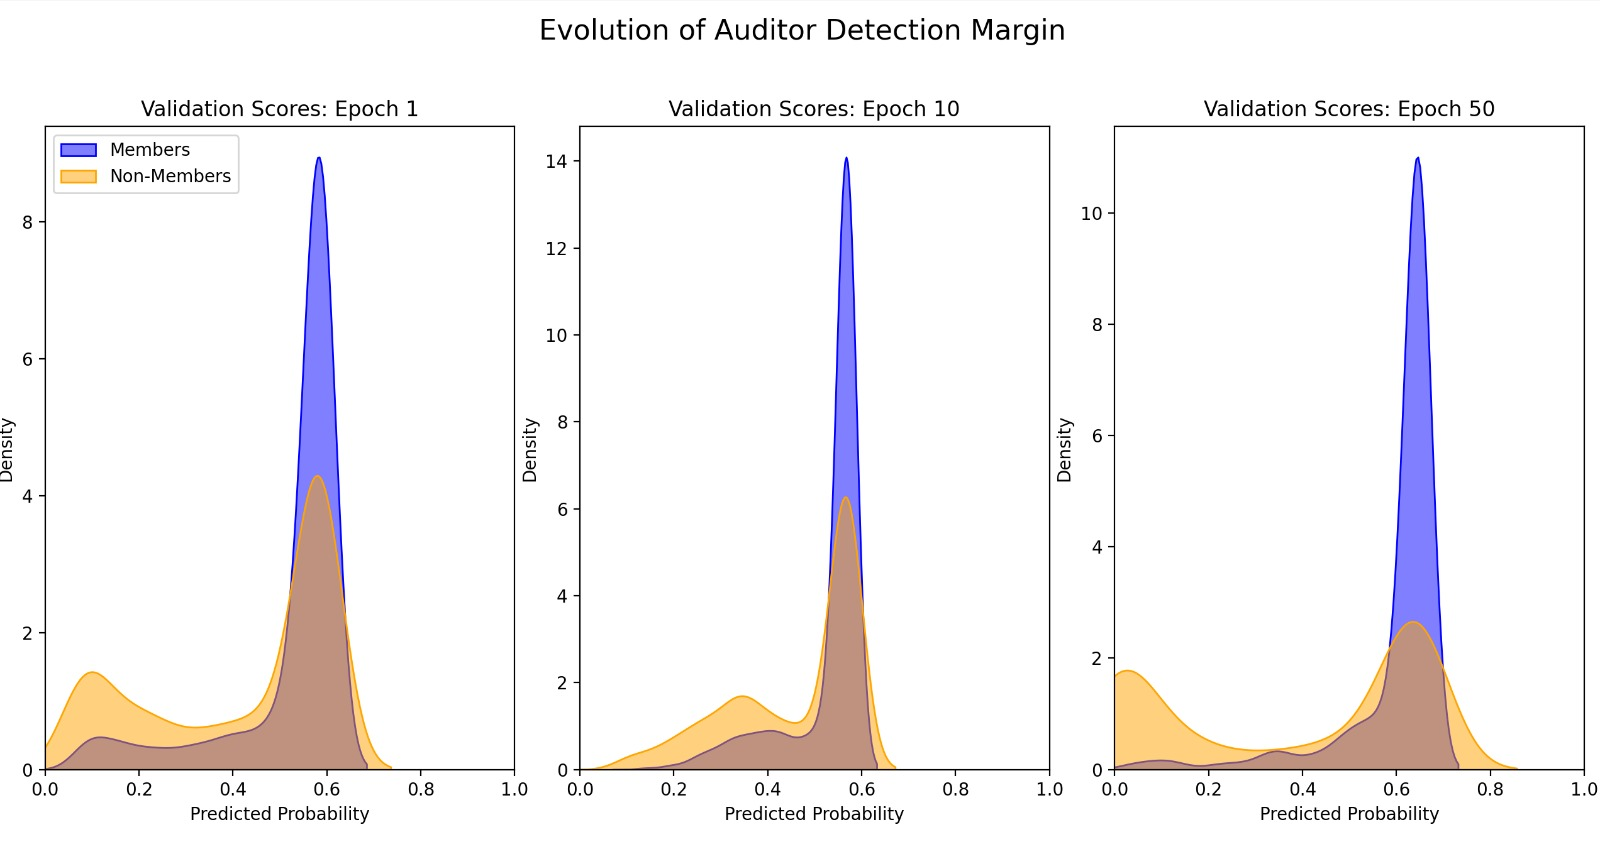

## Phase 4: Final Evaluation
**Generated by:** `evaluate_auditor.py`

Finally, we test our fully trained detective on a massive batch of trajectories it has never seen before to see how well it catches privacy leaks in a real-world scenario.

[Confusion Matrix]
**What this shows:** This grid breaks down the exact number of correct and incorrect guesses. The dark blue squares are where the detective got it right (correctly identifying over 4,500 members and over 2,500 non-members). The lighter squares show its mistakes.

[ROC Curve]
**What this shows:** The Receiver Operating Characteristic (ROC) curve is the standard grading metric for these attacks. The dotted line represents totally random guessing. Our orange line arches high above it, proving our sequence-aware auditor has successfully and reliably detected the model's privacy leaks.

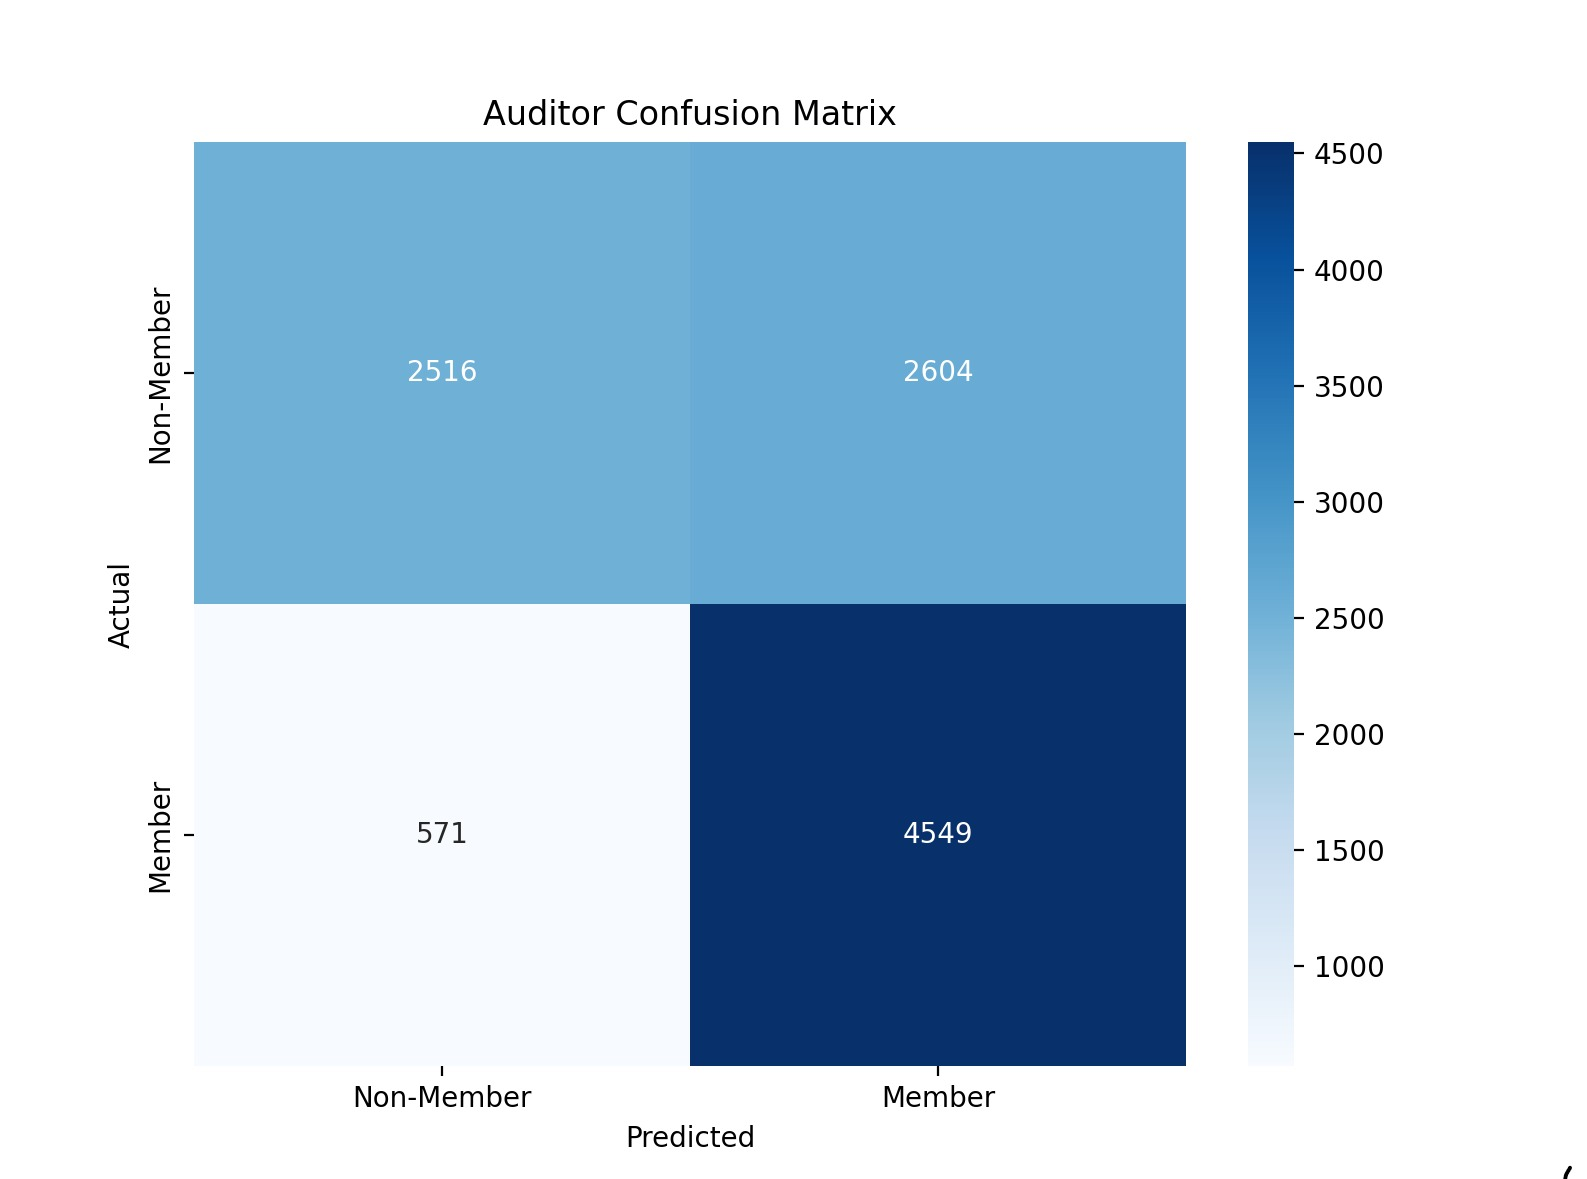

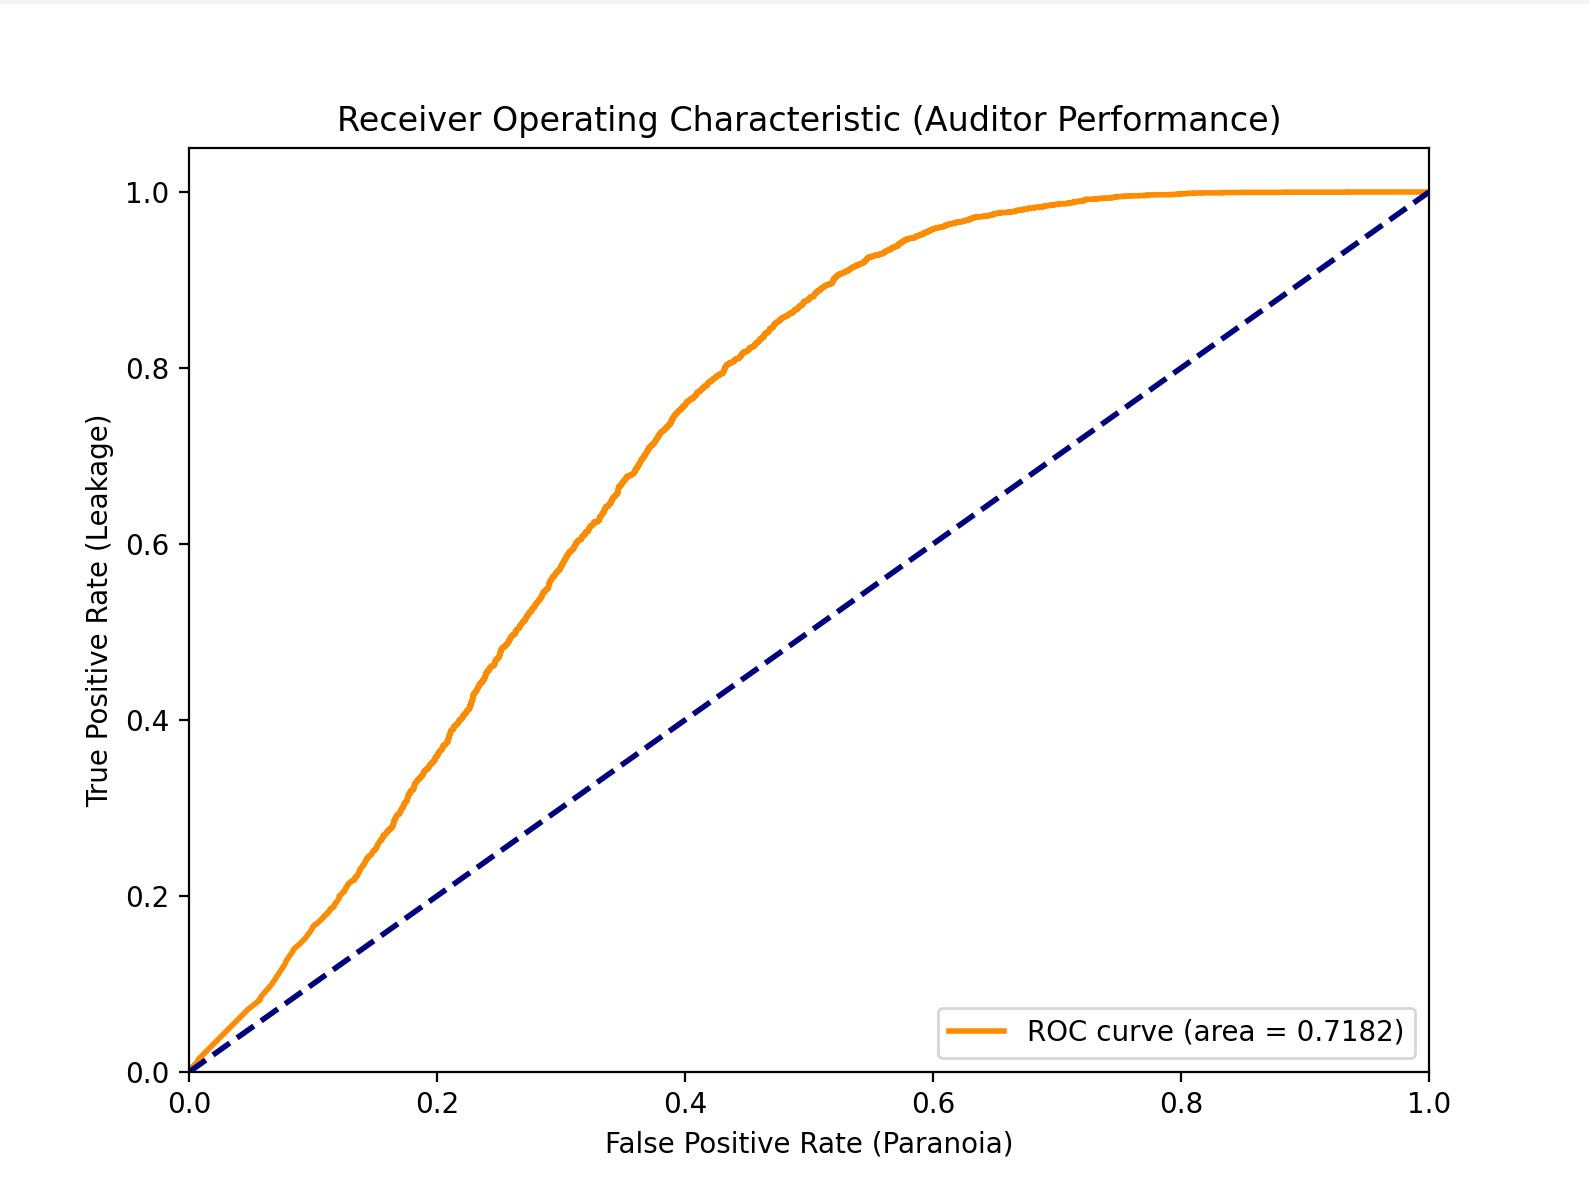

## Phase 3: Auditor Evaluation
**Generated by:** `evaluate_auditor.py`

### 1. Key Performance Metrics
* **Accuracy (69.09%):** Overall percentage of correct predictions.
* **Precision (63.95%):** Success rate when identifying a sample as a member.
* **Recall (87.50%):** Percentage of total members correctly identified.
* **F1-Score (73.90%)**
* **ROC AUC (0.7190):** Measure of how well the model separates members from non-members.